# Instrument cross calibration

Most of the time, when dealing with multiple X-ray instruments, one would want to account for the differences in calibrations between all observatories. The straightforward way to do this with `jaxspec` is to use an [`InstrumentModel`](/references/instrument/#jaxspec.model.instrument.InstrumentModel). Let's first load observations from PN, MOS1 and MOS2.

In [1]:
%%capture
# Hide the output of this cell
import numpyro

numpyro.enable_x64()
numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)

import numpyro.distributions as dist
from jaxspec.fit import VIFitter
from jaxspec.data.util import load_example_obsconf
from jaxspec.model.additive import Blackbodyrad, Powerlaw
from jaxspec.model.multiplicative import Tbabs
from jaxspec.model.background import BackgroundWithError

spectral_model = Tbabs()*(Powerlaw() + Blackbodyrad())

obsconfs = load_example_obsconf("NGC7793_ULX4_ALL")

prior = {
    "spectrum.powerlaw_1.alpha": dist.Uniform(1, 3),
    "spectrum.powerlaw_1.norm": dist.LogUniform(1e-5, 1e-3),
    "spectrum.blackbodyrad_1.kT": dist.Uniform(0, 2),
    "spectrum.blackbodyrad_1.norm": dist.LogUniform(1e-2, 1),
    "spectrum.tbabs_1.nh": dist.Uniform(0, 1)
}

An [`InstrumentModel`](/references/instrument/#jaxspec.model.instrument.InstrumentModel) can be constructed from a [`ConstantGain`](/references/instrument/#jaxspec.model.instrument.ConstantGain) and a [`ConstantShift`](/references/instrument/#jaxspec.model.instrument.ConstantShift). Their priors live in the unified prior dict under `instrument.gain.factor` and `instrument.shift.offset`. For instance, in the following observations, we will use the PN one as the reference, and specify it using `"PN"` because it is the key corresponding to this observation in the dictionary of observations we use.

In [2]:
import numpyro.distributions as dist
from jaxspec.model.background import BackgroundWithError
from jaxspec.model.instrument import InstrumentModel, ConstantGain, ConstantShift
from jaxspec.fit import PerObs

instrument_prior = {
    **prior,
    "instrument.gain.factor": PerObs(dist.Uniform(0.5, 1.5)),  # Uniform between 50 % and 150% of calibration error
    "instrument.shift.offset": PerObs(dist.Uniform(-0.3, +0.3)),  # Assume a shift between -300 and +300 eV
}

fitter = VIFitter(
    spectral_model, instrument_prior, obsconfs,
    instrument_model=InstrumentModel(
        "PN",
        gain_model=ConstantGain(),
        shift_model=ConstantShift(),
    ),
    background_model=BackgroundWithError(),
)

Now lets fit the data as usual

In [4]:
result = fitter.fit(num_steps=30_000, num_samples=10_000)

100%|██████████| 30000/30000 [01:11<00:00, 421.85it/s, init loss: 136633.5998, avg. loss [28501-30000]: 1627.2572]


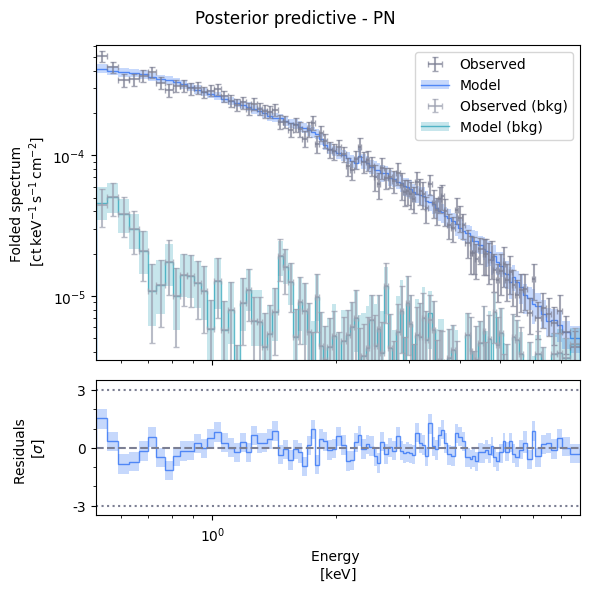

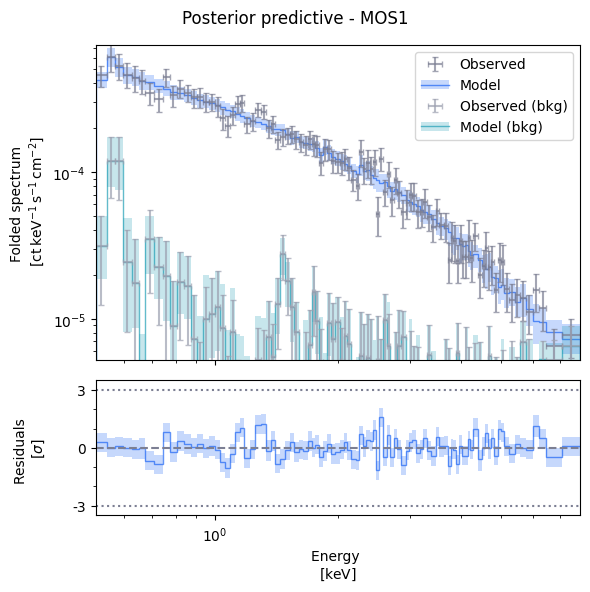

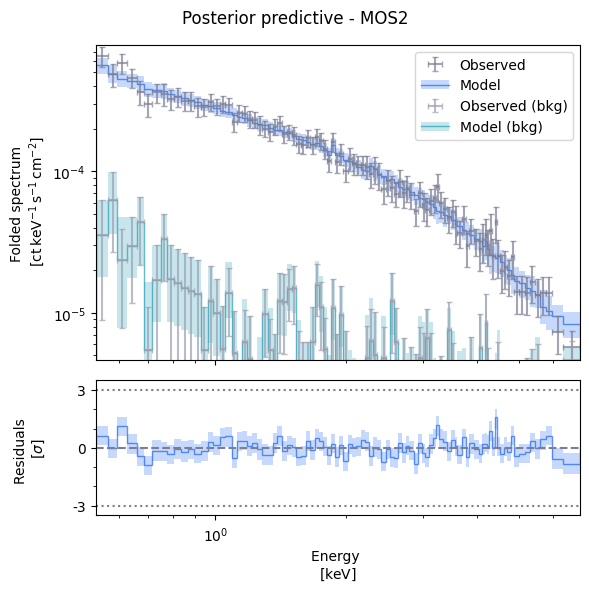

In [5]:
result.plot_ppc();

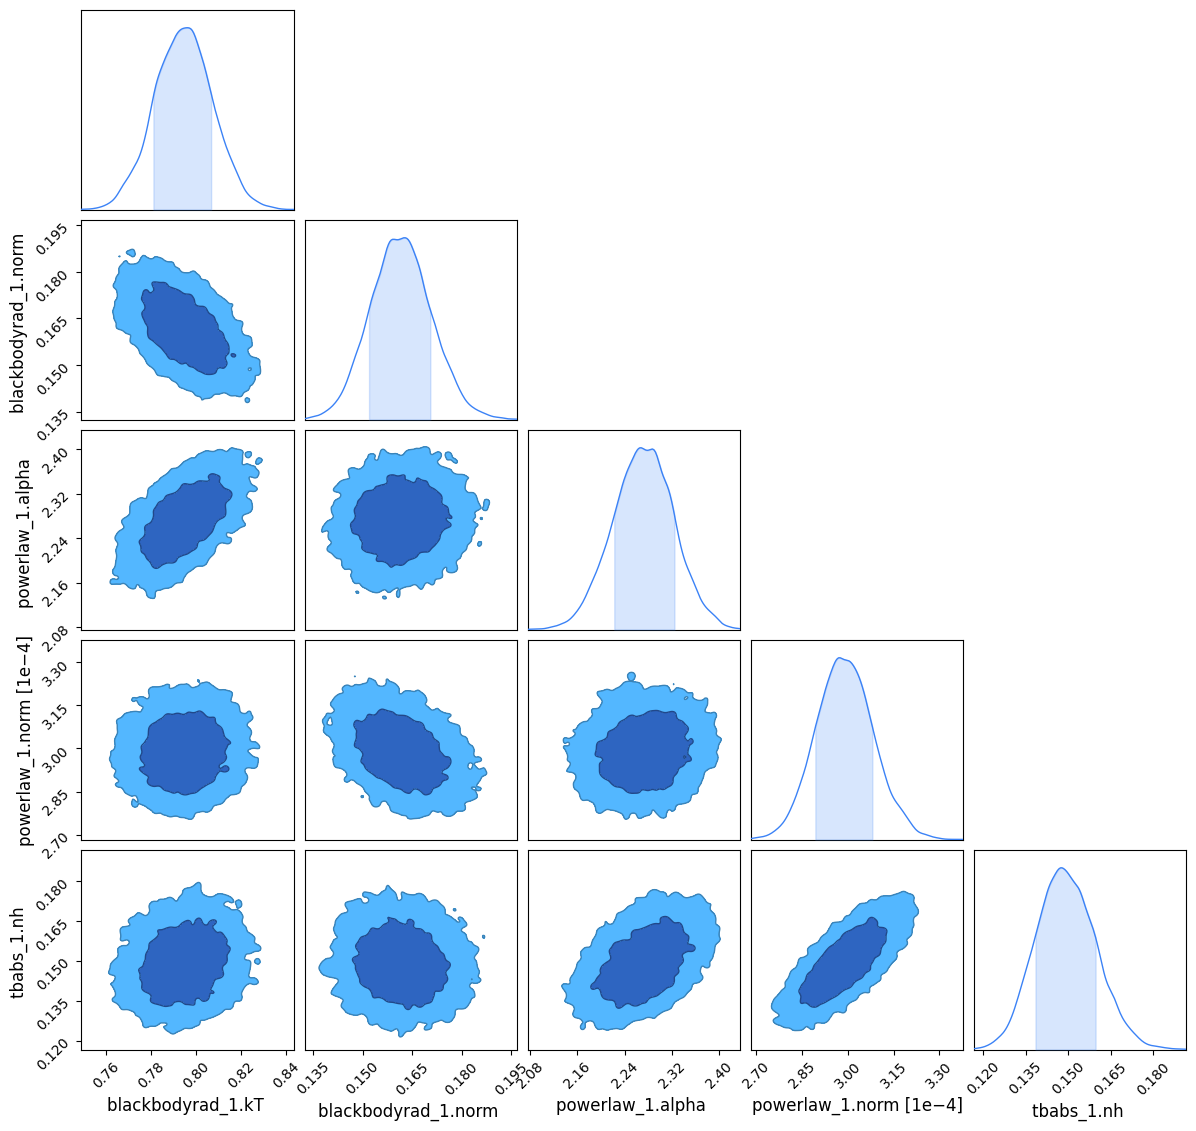

In [6]:
result.plot_corner()

The associated calibrations can be found in the `result` object and accessed as follows

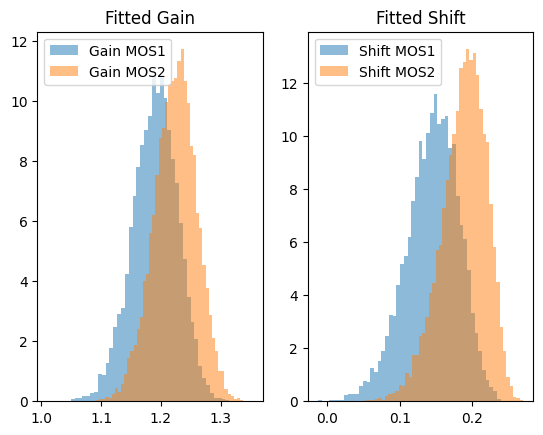

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.close('all')
plt.subplot(121)
plt.hist(np.ravel(result.inference_data.posterior["instrument.gain.factor.MOS1"]), label="Gain MOS1", alpha=0.5, bins=50, density=True)
plt.hist(np.ravel(result.inference_data.posterior["instrument.gain.factor.MOS2"]), label="Gain MOS2", alpha=0.5, bins=50, density=True)
plt.title("Fitted Gain")
plt.legend()

plt.subplot(122)
plt.hist(np.ravel(result.inference_data.posterior["instrument.shift.offset.MOS1"]), label="Shift MOS1", alpha=0.5, bins=50, density=True)
plt.hist(np.ravel(result.inference_data.posterior["instrument.shift.offset.MOS2"]), label="Shift MOS2", alpha=0.5, bins=50, density=True)
plt.title("Fitted Shift")
plt.legend()
plt.show()